# Time Series Basics and COVID19 Time Series Application. 

## Overview

The purpose of this section is to explore Pandas time series and datestamp fundamentals.  After some fundamentals of how time series are represented with Series and dataframes, we will explore the COVID19 state level datasets and demonstrate some of the time series functionality. 

## Libraries

In [1]:
## Import Modules
import os
import sys

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from patsy import dmatrices
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels

import textwrap
import datetime

In [2]:
## Enable inline plotting for graphics
%matplotlib inline

In [3]:
# So all output comes through from Ipython
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [4]:
print(textwrap.fill(sys.version),'\n')
print("Pandas version: {0}".format(pd.__version__),'\n')
print("Matplotlib version: {0}".format(matplotlib.__version__),'\n')
print("Numpy version: {0}".format(np.__version__),'\n')
print("Statsmodels version: {0}".format(statsmodels.__version__))

3.8.8 (default, Apr 13 2021, 12:59:45)  [Clang 10.0.0 ] 

Pandas version: 1.2.4 

Matplotlib version: 3.3.4 

Numpy version: 1.20.1 

Statsmodels version: 0.12.2


## Check your working directory

Subsequent sessions may require you to identify and update your working directory so paths correctly point at the downloaded data files. You can check your working directory like so:

In [5]:
# Working Directory
print(os.getcwd())

/Users/jemmanelson/Desktop/CDC_revisions_Nov21/2-nu_draft


You can simply assign the working directory to be 'one level above the current directory' by running this line of code with the `..` as the path. 
  
`..` means 'one directory above the current directory.
  
Note you should only run it once! If you run it multiple times, you will keep reseting the working directory to one level above the current directory, until you reach the root of the drive!

In [6]:
# Set Working Directory (if needed)
# you can just do this:
os.chdir(r"..") 

For the purpose of compiling these notebooks, I put my working directory here, but this line of code will give you an error since this location does not exist on your file system! I have included the `try` command to avoid the error preventing the rest of the notebook from running in case you miss this.

You could update this string: `r"C:\Users\evancarey\Dropbox\Work"`  

to be a valid path on your filesystem pointing at the course download. 

In [7]:
# Set New Working Directory 
# the try except tells Python to try to run the code
# and if an error occurs, print a message
try:
    os.chdir(r"/Users/jemmanelson/Desktop/CDC_final")
except:
    print("ERROR: You probably forgot to change the directory path!")

ERROR: You probably forgot to change the directory path!


In [8]:
# Confirm it changed the working Directory
print("My working directory:\n" + os.getcwd())

My working directory:
/Users/jemmanelson/Desktop/CDC_revisions_Nov21


## Fundamentals for Dates in Python:

In the next few sections we will cover fundamentals of date and date times in Python as they pertain to Pandas time series analysis. After that we will cover an application of analyzing COVID data in the US.

## Datetime types

Pandas can import datetimes from strings, `numpy,` or the `datetime.datetime` module. These are the three most common sources for datetime-like values:

In [9]:
#pandas datestamp from string
pd.to_datetime('Feb 2 2020')

Timestamp('2020-02-02 00:00:00')

In [10]:
#numpy datetime
np_date = np.datetime64('2020-02-14')
print(np_date)
pd.to_datetime(np_date)

2020-02-14


Timestamp('2020-02-14 00:00:00')

In [11]:
#datetime module datetime
dt_date = datetime.datetime(2020,2,28)
print(dt_date)
pd.to_datetime(dt_date)

2020-02-28 00:00:00


Timestamp('2020-02-28 00:00:00')

## Numpy Datetimes

As a side note on numpy datetimes, this dtype allows for vectorized calculations on a native numpy object, using broadcasting and ufuncs.

The input must be a string of the 'YYYY-MM-DD' format.

In [12]:
np_date

numpy.datetime64('2020-02-14')

In [13]:
np_dates = np_date + np.arange(12)
np_dates

array(['2020-02-14', '2020-02-15', '2020-02-16', '2020-02-17',
       '2020-02-18', '2020-02-19', '2020-02-20', '2020-02-21',
       '2020-02-22', '2020-02-23', '2020-02-24', '2020-02-25'],
      dtype='datetime64[D]')

In [14]:
np_dates.dtype
np_dates.shape

dtype('<M8[D]')

(12,)

## Numpy Datetimes

Timezones are automatically added according to the computer's local time zone.

Also, we can force finer-grained time by specifying it during creation (below, nano-seconds).

In [15]:
np.datetime64('2020-02-04 14:14')
np.datetime64('2020-02-04 14:30:30.14', 'ns') 
#nanosecond is the maximum precision

numpy.datetime64('2020-02-04T14:14')

numpy.datetime64('2020-02-04T14:30:30.140000000')

You can find a table of the time codes in the Handbook here: https://jakevdp.github.io/PythonDataScienceHandbook/03.11-working-with-time-series.html

## Pandas Date Ranges

The date_range method generates ranges from a start to end at a specific frequency.

Frequency aliases are shortcodes like

- 'H' : hourly
- 'W' : weekly
- 'M' : monthly, specifically month-end
- 'BQ' : business quarter end


You can find a table of the frequency aliases here: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-offset-aliases

In [16]:
dt_range = pd.date_range('2020-01-01', periods=24, freq='H')
dt_range

DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 01:00:00',
               '2020-01-01 02:00:00', '2020-01-01 03:00:00',
               '2020-01-01 04:00:00', '2020-01-01 05:00:00',
               '2020-01-01 06:00:00', '2020-01-01 07:00:00',
               '2020-01-01 08:00:00', '2020-01-01 09:00:00',
               '2020-01-01 10:00:00', '2020-01-01 11:00:00',
               '2020-01-01 12:00:00', '2020-01-01 13:00:00',
               '2020-01-01 14:00:00', '2020-01-01 15:00:00',
               '2020-01-01 16:00:00', '2020-01-01 17:00:00',
               '2020-01-01 18:00:00', '2020-01-01 19:00:00',
               '2020-01-01 20:00:00', '2020-01-01 21:00:00',
               '2020-01-01 22:00:00', '2020-01-01 23:00:00'],
              dtype='datetime64[ns]', freq='H')

## Pandas Time Zone

You can convert a time to a particular time zone

In [17]:
dt_range.tz_localize('US/Pacific')

DatetimeIndex(['2020-01-01 00:00:00-08:00', '2020-01-01 01:00:00-08:00',
               '2020-01-01 02:00:00-08:00', '2020-01-01 03:00:00-08:00',
               '2020-01-01 04:00:00-08:00', '2020-01-01 05:00:00-08:00',
               '2020-01-01 06:00:00-08:00', '2020-01-01 07:00:00-08:00',
               '2020-01-01 08:00:00-08:00', '2020-01-01 09:00:00-08:00',
               '2020-01-01 10:00:00-08:00', '2020-01-01 11:00:00-08:00',
               '2020-01-01 12:00:00-08:00', '2020-01-01 13:00:00-08:00',
               '2020-01-01 14:00:00-08:00', '2020-01-01 15:00:00-08:00',
               '2020-01-01 16:00:00-08:00', '2020-01-01 17:00:00-08:00',
               '2020-01-01 18:00:00-08:00', '2020-01-01 19:00:00-08:00',
               '2020-01-01 20:00:00-08:00', '2020-01-01 21:00:00-08:00',
               '2020-01-01 22:00:00-08:00', '2020-01-01 23:00:00-08:00'],
              dtype='datetime64[ns, US/Pacific]', freq=None)

## Date and Time Arithmetic

We can add timedeltas or offsets to times.

In [18]:
pd.Timestamp.today()

Timestamp('2021-11-19 08:21:25.522854')

In [19]:
dt_range[-1].day_name()
dt_range[-1]

'Wednesday'

Timestamp('2020-01-01 23:00:00', freq='H')

In [20]:
dt_range[-1] + pd.Timedelta('1 Hour')
dt_range[-1] + pd.Timedelta('1 Day')
dt_range[-1] + pd.Timedelta('1 Minute')

Timestamp('2020-01-02 00:00:00', freq='H')

Timestamp('2020-01-02 23:00:00', freq='H')

Timestamp('2020-01-01 23:01:00', freq='H')

In [21]:
pd.to_datetime('01-31-2020').day_name()
(pd.to_datetime('01-31-2020') + pd.offsets.BDay()).day_name() #add 1 business day

'Friday'

'Monday'

## Datetime Objects

In fact, Pandas represents 4 distinct kind of datetime objects internally. These are:

- **Timestamp,** a date and time with timezone support
- **Timedelta,** an absolute time duration
- **Period,** a span in time represented by a point and a frequency
- **DateOffset,** a relative time duration that respects calendar arithmetic (like holidays and business days)

## Time as Index to make a Time Series

By placing time on an Pandas index, we can do fancy indexing. However, time can also be a data component (variable).


<AxesSubplot:>

2000-01-01    12.149078
2000-01-02    17.715773
2000-01-03    16.286344
2000-01-04    11.580480
2000-01-05     8.516259
Freq: D, dtype: float64

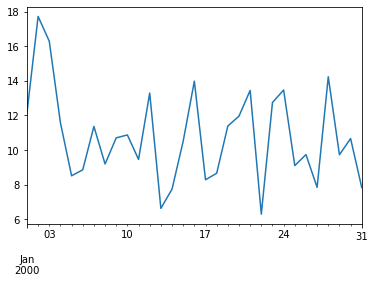

In [22]:
jan = pd.Series(np.random.normal(10,3,31), 
                index=pd.date_range('2000', freq='D', periods=31))
jan.plot()
jan.head()

## Epoch Time

Pandas can convert from epoch time, or when the time unit is represented as a floating point number from an origin point. The default unit is nanoseconds, but other units can be specified.


In [23]:
epochs = np.array([1583064000]) + np.arange(1,30)*1000
epochs

array([1583065000, 1583066000, 1583067000, 1583068000, 1583069000,
       1583070000, 1583071000, 1583072000, 1583073000, 1583074000,
       1583075000, 1583076000, 1583077000, 1583078000, 1583079000,
       1583080000, 1583081000, 1583082000, 1583083000, 1583084000,
       1583085000, 1583086000, 1583087000, 1583088000, 1583089000,
       1583090000, 1583091000, 1583092000, 1583093000])

In [24]:
pd.to_datetime(epochs,unit='s').tz_localize('US/Eastern')

DatetimeIndex(['2020-03-01 12:16:40-05:00', '2020-03-01 12:33:20-05:00',
               '2020-03-01 12:50:00-05:00', '2020-03-01 13:06:40-05:00',
               '2020-03-01 13:23:20-05:00', '2020-03-01 13:40:00-05:00',
               '2020-03-01 13:56:40-05:00', '2020-03-01 14:13:20-05:00',
               '2020-03-01 14:30:00-05:00', '2020-03-01 14:46:40-05:00',
               '2020-03-01 15:03:20-05:00', '2020-03-01 15:20:00-05:00',
               '2020-03-01 15:36:40-05:00', '2020-03-01 15:53:20-05:00',
               '2020-03-01 16:10:00-05:00', '2020-03-01 16:26:40-05:00',
               '2020-03-01 16:43:20-05:00', '2020-03-01 17:00:00-05:00',
               '2020-03-01 17:16:40-05:00', '2020-03-01 17:33:20-05:00',
               '2020-03-01 17:50:00-05:00', '2020-03-01 18:06:40-05:00',
               '2020-03-01 18:23:20-05:00', '2020-03-01 18:40:00-05:00',
               '2020-03-01 18:56:40-05:00', '2020-03-01 19:13:20-05:00',
               '2020-03-01 19:30:00-05:00', '2020-0

## State subset COVID19 Dataset

Let's use a subset of CDC COVID19 data to apply the time series approaches we saw above on some real applications. 

These are year-month counts from a larger dataset. We've preselected 4 states to make the data more compact.

In [25]:
covid = pd.read_csv('Data/health_data/covid_19/covid_ALNYPAWY.csv',
                   dtype={'state_fips_code':'object',
                          'county_fips_code':'object'}, low_memory=False)

In [26]:
covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4609966 entries, 0 to 4609965
Data columns (total 19 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   case_month                       object 
 1   res_state                        object 
 2   state_fips_code                  object 
 3   res_county                       object 
 4   county_fips_code                 object 
 5   age_group                        object 
 6   sex                              object 
 7   race                             object 
 8   ethnicity                        object 
 9   case_positive_specimen_interval  float64
 10  case_onset_interval              float64
 11  process                          object 
 12  exposure_yn                      object 
 13  current_status                   object 
 14  symptom_status                   object 
 15  hosp_yn                          object 
 16  icu_yn                           object 
 17  death_yn

These have county data, which might be useful for more detail.

In [27]:
# All 4 states
covid['res_state'].value_counts()

NY    2430681
PA    1356858
AL     739555
WY      82872
Name: res_state, dtype: int64

And there are 4 US states represented.

We start by converting the date to an actual date time object:

In [28]:
# convert to a date
covid['date_dt'] = \
    pd.to_datetime(covid['case_month'])

We need to "roll up" the data to make counts. Let's say we are interested in the case count, the hospitalizations, deaths, and icu admissions.
- first, let's explore those variables.
- the rows of this dataset represent cases. So a count or rows will provide us with case counts.
- we want to roll up on state and case_month, so let's include both of those in our groupby.
- state_fips_code is a complete variable, so let's use that for counting observations.

In [29]:
covid.count()

case_month                         4609966
res_state                          4609966
state_fips_code                    4609966
res_county                         4494819
county_fips_code                   4494819
age_group                          4564735
sex                                4503358
race                               3833584
ethnicity                          3734765
case_positive_specimen_interval    3077947
case_onset_interval                1361498
process                            4609966
exposure_yn                        4609966
current_status                     4609966
symptom_status                     4609966
hosp_yn                            4609966
icu_yn                             4609966
death_yn                           4362080
underlying_conditions_yn            464187
date_dt                            4609966
dtype: int64

In [30]:
# Note the multi-index result.
covid_cases = covid.groupby(['res_state','case_month'])['state_fips_code'].count()
covid_cases

res_state  case_month
AL         2020-01          45
           2020-02          56
           2020-03        2673
           2020-04        6207
           2020-05       11431
                         ...  
WY         2021-05        2110
           2021-06        1974
           2021-07        3320
           2021-08       12131
           2021-09        5774
Name: state_fips_code, Length: 82, dtype: int64

In [31]:
covid['hosp_yn'].value_counts(dropna=False)

Missing    2511121
Unknown    1137120
No          736407
Yes         225318
Name: hosp_yn, dtype: int64

Hmm, for our purposes we'll turn the "Missing" and "Unknown" into missing values (NA). Let's do that across the whole dataset, as these values might occur in other columns as well.

In [32]:
covid_clean = covid.replace(to_replace=["Missing","Unknown"],value=np.nan)
covid_clean['hosp_yn'].value_counts(dropna=False)

NaN    3648241
No      736407
Yes     225318
Name: hosp_yn, dtype: int64

Next, we want to count "Yes" and sum them all up. Let's replace all "No" and "Yes" values with 0 and 1. Again, we will do this across all variables that might have "Yes/No" formats.

In [33]:
covid_clean = covid_clean.replace(to_replace=["No","Yes"],value=[0,1])

In [34]:
covid_clean['hosp_yn'].value_counts(dropna=False)

NaN    3648241
0.0     736407
1.0     225318
Name: hosp_yn, dtype: int64

Great! Now we can do some aggregation using `sum()`, and then finally merge the information we want together to make a nice, neat, time series.

In [35]:
covid_sums = covid_clean[['res_state','case_month','hosp_yn','death_yn','icu_yn']].\
                groupby(['res_state','case_month']).sum()
covid_sums

hosp_yn  death_yn  icu_yn
res_state case_month                           
AL        2020-01         4.0       0.0     0.0
          2020-02        12.0       0.0     0.0
          2020-03       478.0      22.0     0.0
          2020-04       869.0     224.0     1.0
          2020-05       947.0     161.0     0.0
...                       ...       ...     ...
WY        2021-05       119.0       0.0    38.0
          2021-06        88.0       0.0    24.0
          2021-07       156.0       0.0    40.0
          2021-08       240.0       0.0    54.0
          2021-09       113.0       0.0    22.0

[82 rows x 3 columns]

In [36]:
covid_ts = covid_sums.join(covid_cases).reset_index()
covid_ts.columns = ['res_state', 'case_month', 'hosp_yn', 'death_yn', 'icu_yn', 'case_count']
covid_ts

,res_state,case_month,hosp_yn,death_yn,icu_yn,case_count
0,AL,2020-01,4.0,0.0,0.0,45
1,AL,2020-02,12.0,0.0,0.0,56
2,AL,2020-03,478.0,22.0,0.0,2673
3,AL,2020-04,869.0,224.0,1.0,6207
4,AL,2020-05,947.0,161.0,0.0,11431
...,...,...,...,...,...,...
77,WY,2021-05,119.0,0.0,38.0,2110
78,WY,2021-06,88.0,0.0,24.0,1974
79,WY,2021-07,156.0,0.0,40.0,3320
80,WY,2021-08,240.0,0.0,54.0,12131


## Simplifying it down to be a typical "time series", start with New York

By time series, we mean a data container that has a time stamp index, and then whatever measurements in a single column. We can also have data in multiple columns, as long as the index (the time stamp) applies to each column. In that case each column would be a separate thing measured on the same day (time). 

Having the index as a time stamp allows us to do (as we will see): 

* fancy indexing based on partial date matches
* resampling to lower frequency


We will focus on New York first:

In [37]:
# focus on one state and counts
covid_ny = covid_ts.query('res_state == "NY"').copy() #copy-make sure we're not working on a slice
covid_ny['case_month_dt'] = pd.to_datetime(covid_ny['case_month']) # we lost the reformatting we did above
covid_ny = covid_ny.set_index('case_month_dt')
covid_ny

,res_state,case_month,hosp_yn,death_yn,icu_yn,case_count
case_month_dt,,,,,,
2020-01-01,NY,2020-01,48.0,0.0,5.0,448
2020-02-01,NY,2020-02,850.0,73.0,55.0,1038
2020-03-01,NY,2020-03,28407.0,10061.0,3717.0,130106
2020-04-01,NY,2020-04,37123.0,20539.0,2640.0,226260
2020-05-01,NY,2020-05,6418.0,2158.0,417.0,134775
2020-06-01,NY,2020-06,2457.0,303.0,116.0,68376
2020-07-01,NY,2020-07,2025.0,86.0,99.0,58900
2020-08-01,NY,2020-08,1579.0,47.0,73.0,44071
2020-09-01,NY,2020-09,1633.0,83.0,129.0,46980


If we call the plot method on the object, a line plot will automatically be plotted with sensical dates on the X axis:

<AxesSubplot:xlabel='case_month_dt'>

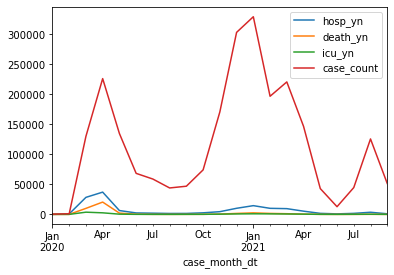

In [38]:
# View time series
covid_ny.plot()

## Lagged Differences


In addition to the total case counts, we are also likely interested in the changes case counts. Since the data is sorted by the date index, we can simply calculate them through the diff function with a period of one:

In [39]:
# calculate daily new cases by lagging
covid_ny['monthly_new'] = \
    covid_ny['case_count'].diff(periods=1)
covid_ny

,res_state,case_month,hosp_yn,death_yn,icu_yn,case_count,monthly_new
case_month_dt,,,,,,,
2020-01-01,NY,2020-01,48.0,0.0,5.0,448,NaN
2020-02-01,NY,2020-02,850.0,73.0,55.0,1038,590.0
2020-03-01,NY,2020-03,28407.0,10061.0,3717.0,130106,129068.0
2020-04-01,NY,2020-04,37123.0,20539.0,2640.0,226260,96154.0
2020-05-01,NY,2020-05,6418.0,2158.0,417.0,134775,-91485.0
2020-06-01,NY,2020-06,2457.0,303.0,116.0,68376,-66399.0
2020-07-01,NY,2020-07,2025.0,86.0,99.0,58900,-9476.0
2020-08-01,NY,2020-08,1579.0,47.0,73.0,44071,-14829.0
2020-09-01,NY,2020-09,1633.0,83.0,129.0,46980,2909.0


<AxesSubplot:xlabel='case_month_dt'>

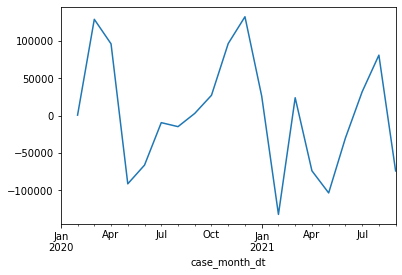

In [40]:
# plot daily new
covid_ny['monthly_new'].plot()

## Filling in missing data

There is no missing data in this aggregated time series, but what if there were?

There are a few different options in Pandas for imputing missing data. The `fillna` method will allow a us to impute the most recent value (forward fill), which could be appropriate here. We could also do an interpolation (draw a line across values) to fill in the missing data using the `.interpolate()` method. We will use a linear interpolation here: 

<AxesSubplot:xlabel='case_month_dt'>

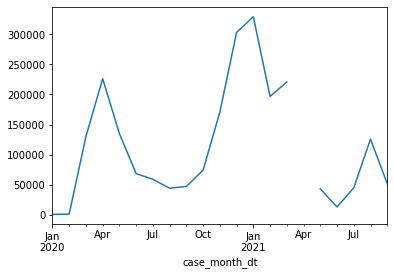

In [41]:
# create a missing value
covid_ny_nan = covid_ny
covid_ny_nan.loc["2021-04-01","case_count"] = np.nan
covid_ny_nan['case_count'].plot()

<AxesSubplot:xlabel='case_month_dt'>

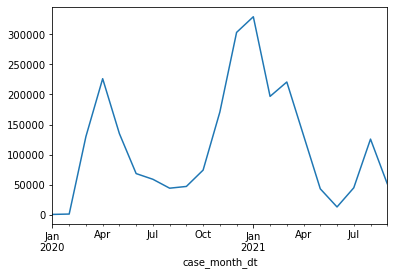

In [42]:
# plot daily new on fixed data
covid_ny_nan['case_count'].interpolate().plot()

And now the plot looks much better.

Another potential variable of interest is the percent change in monthly new cases. This is easily calculated through the `pct_change()` method in Pandas:

In [43]:
# We can also calculate percent change of daily new cases
covid_ny['monthly_pct_change'] = \
    covid_ny['monthly_new']\
    .pct_change()

In [44]:
covid_ny['monthly_pct_change']

case_month_dt
2020-01-01           NaN
2020-02-01           NaN
2020-03-01    217.759322
2020-04-01     -0.255013
2020-05-01     -1.951442
2020-06-01     -0.274209
2020-07-01     -0.857287
2020-08-01      0.564901
2020-09-01     -1.196170
2020-10-01      8.353730
2020-11-01      2.549247
2020-12-01      0.372115
2021-01-01     -0.803354
2021-02-01     -6.084772
2021-03-01     -1.180439
2021-04-01     -4.096495
2021-05-01      0.400670
2021-06-01     -0.709064
2021-07-01     -2.056649
2021-08-01      1.541582
2021-09-01     -1.916191
Name: monthly_pct_change, dtype: float64

<AxesSubplot:xlabel='case_month_dt'>

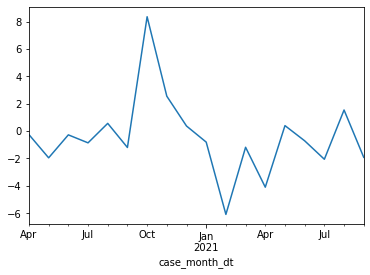

In [45]:
# plot percent change
covid_ny.loc["2020-04":,'monthly_pct_change'].plot()

## Applying rolling functions to calculate moving averages

We just saw a fair bit of apparent structural noise in the time series by looking at the percent change plot. It is often of interest to try and de-noise a curve like this (separate the curve into noise and trend components). Although the topic of de-noising a time series is a fairly comprehensive thing to cover, we will cover a simple approach such as calculating a moving average. Pandas allows us to apply rolling functions to a dataset. This makes a lot of sense where row order matters (such as a time series). In this simple example below we are using evenly weighted windows (all observations in a window equally contribute to the calculation, mean in this case). Pandas does allow you to specify more complex windowing functions - check it out here: 

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html

In this data, the monthly counts probably can't be averaged in a sensical way, but we show this for illustration. If you had finer grained data, like daily counts, this would "smooth" the curve.

In [46]:
# smooth with 3 day moving average (center = true is taking information from the future! This may not be appropriate in some cases)
covid_ny['monthly_new_MA_3'] = \
    covid_ny\
    .rolling(window=3, center = True)['monthly_new'].mean()

<AxesSubplot:xlabel='case_month_dt'>

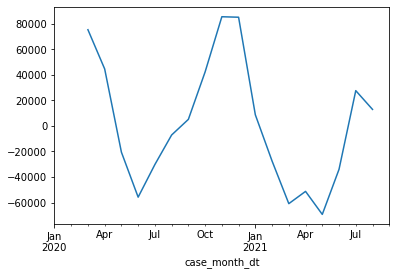

In [47]:
# plot
covid_ny['monthly_new_MA_3'].plot()

## Resampling to a higher level

We can `resample()` using the resample command. It takes various abbreviations for frequency, like `Q` for quarter, `D` for daily, `M` for monthly (end of month), or `MS` for month start.

After we resample, we can apply the mean function on the resamples to get an aggreate summary. 

In [48]:
# resample weekly numbers 'w' means week
covid_ny_quarterly = \
    covid_ny[['case_count','monthly_new']]\
    .resample('Q')\
    .mean()
covid_ny_quarterly

,case_count,monthly_new
case_month_dt,,
2020-03-31,43864.000000,64829.000000
2020-06-30,143137.000000,-20576.666667
2020-09-30,49983.666667,-7132.000000
2020-12-31,182744.000000,85432.333333
2021-03-31,248971.666667,-27511.000000
2021-06-30,27936.000000,-69297.333333
2021-09-30,73998.333333,12889.000000


In [49]:
covid_ny_quarterly.index

DatetimeIndex(['2020-03-31', '2020-06-30', '2020-09-30', '2020-12-31',
               '2021-03-31', '2021-06-30', '2021-09-30'],
              dtype='datetime64[ns]', name='case_month_dt', freq='Q-DEC')

<AxesSubplot:xlabel='case_month_dt'>

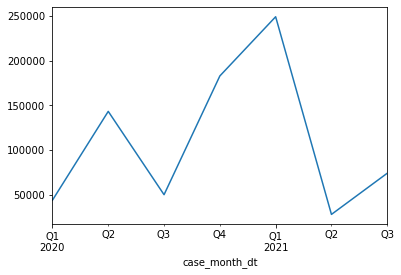

In [50]:
# plot weekly numbers
covid_ny_quarterly['case_count'].plot()

## Slicing Time Series

We can use the DatetimeIndex to slice down to reasonable periods within the time series. Since the index is a date object, Pandas will interpret these text slices as dates using partial string matching.

In [51]:
# slice data
covid_ny['2020-08':'2020-12']

,res_state,case_month,hosp_yn,death_yn,icu_yn,case_count,monthly_new,monthly_pct_change,monthly_new_MA_3
case_month_dt,,,,,,,,,
2020-08-01,NY,2020-08,1579.0,47.0,73.0,44071.0,-14829.0,0.564901,-7132.000000
2020-09-01,NY,2020-09,1633.0,83.0,129.0,46980.0,2909.0,-1.196170,5096.666667
2020-10-01,NY,2020-10,2643.0,99.0,196.0,74190.0,27210.0,8.353730,42231.333333
2020-11-01,NY,2020-11,4551.0,533.0,429.0,170765.0,96575.0,2.549247,85432.333333
2020-12-01,NY,2020-12,10198.0,1656.0,802.0,303277.0,132512.0,0.372115,85048.333333


<AxesSubplot:xlabel='case_month_dt'>

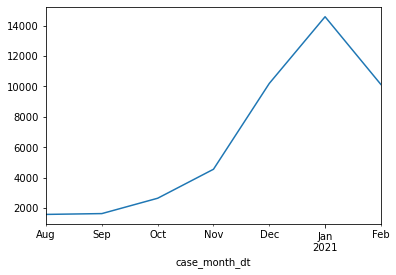

In [52]:
# Plot time series on a slice
covid_ny['2020-08-01':'2021-02-01']['hosp_yn'].plot()

## Repeat this for multiple states

We have shown how to use the syntax to analyze one state at a time (one series at a time). But how can we adopt this same approach to analyzing multiple states? Let's return to the `covid_ts` object with all the different states we created above. 

In [53]:
# Check max, min, counts for each state in our subset
covid_ts['date'] = pd.to_datetime(covid_ts['case_month'])
covid_ts = covid_ts.set_index('date')
covid_ts

,res_state,case_month,hosp_yn,death_yn,icu_yn,case_count
date,,,,,,
2020-01-01,AL,2020-01,4.0,0.0,0.0,45
2020-02-01,AL,2020-02,12.0,0.0,0.0,56
2020-03-01,AL,2020-03,478.0,22.0,0.0,2673
2020-04-01,AL,2020-04,869.0,224.0,1.0,6207
2020-05-01,AL,2020-05,947.0,161.0,0.0,11431
...,...,...,...,...,...,...
2021-05-01,WY,2021-05,119.0,0.0,38.0,2110
2021-06-01,WY,2021-06,88.0,0.0,24.0,1974
2021-07-01,WY,2021-07,156.0,0.0,40.0,3320


res_state
AL    AxesSubplot(0.125,0.125;0.775x0.755)
NY    AxesSubplot(0.125,0.125;0.775x0.755)
PA    AxesSubplot(0.125,0.125;0.775x0.755)
WY    AxesSubplot(0.125,0.125;0.775x0.755)
Name: hosp_yn, dtype: object

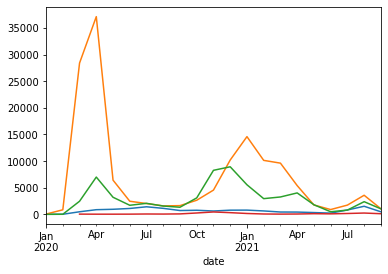

In [54]:
# print the object
covid_ts.groupby('res_state')['hosp_yn'].plot()

Here we will set both the time and state variables as the index. This gives us a multi-index object. This will make life easier later when we apply the rolling statistics. The `groupby()` functionality will work with an index level just as easily as a column level when we apply it in a moment. 

In [55]:
# set time index
covid_ts['date'] = pd.to_datetime(covid_ts['case_month'])
covid_ts_state = covid_ts.set_index(['res_state','date'])
covid_ts_state

case_month  hosp_yn  death_yn  icu_yn  case_count
res_state date                                                        
AL        2020-01-01    2020-01      4.0       0.0     0.0          45
          2020-02-01    2020-02     12.0       0.0     0.0          56
          2020-03-01    2020-03    478.0      22.0     0.0        2673
          2020-04-01    2020-04    869.0     224.0     1.0        6207
          2020-05-01    2020-05    947.0     161.0     0.0       11431
...                         ...      ...       ...     ...         ...
WY        2021-05-01    2021-05    119.0       0.0    38.0        2110
          2021-06-01    2021-06     88.0       0.0    24.0        1974
          2021-07-01    2021-07    156.0       0.0    40.0        3320
          2021-08-01    2021-08    240.0       0.0    54.0       12131
          2021-09-01    2021-09    113.0       0.0    22.0        5774

[82 rows x 5 columns]

I am going to ensure the dataset is sorted by the index:

In [56]:
# sort by index
covid_ts_state.sort_index(inplace=True)
covid_ts_state.drop(columns='case_month',inplace=True)

In [57]:
covid_ts_state

hosp_yn  death_yn  icu_yn  case_count
res_state date                                             
AL        2020-01-01      4.0       0.0     0.0          45
          2020-02-01     12.0       0.0     0.0          56
          2020-03-01    478.0      22.0     0.0        2673
          2020-04-01    869.0     224.0     1.0        6207
          2020-05-01    947.0     161.0     0.0       11431
...                       ...       ...     ...         ...
WY        2021-05-01    119.0       0.0    38.0        2110
          2021-06-01     88.0       0.0    24.0        1974
          2021-07-01    156.0       0.0    40.0        3320
          2021-08-01    240.0       0.0    54.0       12131
          2021-09-01    113.0       0.0    22.0        5774

[82 rows x 4 columns]

## Calculate differences within group

Since we setup the multiindex, we can easily first group the object by state, then calculate the differences within group. 

Note this is calculating the monthly_new cases *per group,* which is this example are the different states.

In [58]:
# calculate daily new by group and add to dataframe
covid_ts_state['monthly_new'] = \
   covid_ts_state\
    .groupby('res_state')['case_count']\
    .diff(periods=1)
covid_ts_state

hosp_yn  death_yn  icu_yn  case_count  monthly_new
res_state date                                                          
AL        2020-01-01      4.0       0.0     0.0          45          NaN
          2020-02-01     12.0       0.0     0.0          56         11.0
          2020-03-01    478.0      22.0     0.0        2673       2617.0
          2020-04-01    869.0     224.0     1.0        6207       3534.0
          2020-05-01    947.0     161.0     0.0       11431       5224.0
...                       ...       ...     ...         ...          ...
WY        2021-05-01    119.0       0.0    38.0        2110        255.0
          2021-06-01     88.0       0.0    24.0        1974       -136.0
          2021-07-01    156.0       0.0    40.0        3320       1346.0
          2021-08-01    240.0       0.0    54.0       12131       8811.0
          2021-09-01    113.0       0.0    22.0        5774      -6357.0

[82 rows x 5 columns]

That looked good! Now what about the missing data...?

## Fill in missing data by group

We adopt the same approach as before - filling in the missing data with the prior value, but doing so within group. 

We don't have missing data here apart from what we introduced with the differencing. But if we did, we could use an approach like this.

In [59]:
# fill in missing with last value carried forward
covid_ts_state['monthly_new_clean'] = \
    covid_ts_state\
    .groupby('res_state')\
    ['monthly_new']\
    .fillna(method='ffill')
covid_ts_state

hosp_yn  death_yn  icu_yn  case_count  monthly_new  \
res_state date                                                             
AL        2020-01-01      4.0       0.0     0.0          45          NaN   
          2020-02-01     12.0       0.0     0.0          56         11.0   
          2020-03-01    478.0      22.0     0.0        2673       2617.0   
          2020-04-01    869.0     224.0     1.0        6207       3534.0   
          2020-05-01    947.0     161.0     0.0       11431       5224.0   
...                       ...       ...     ...         ...          ...   
WY        2021-05-01    119.0       0.0    38.0        2110        255.0   
          2021-06-01     88.0       0.0    24.0        1974       -136.0   
          2021-07-01    156.0       0.0    40.0        3320       1346.0   
          2021-08-01    240.0       0.0    54.0       12131       8811.0   
          2021-09-01    113.0       0.0    22.0        5774      -6357.0   

                      monthly_new_clean  
res_state date                           
AL        2020-01-01                NaN  
          2020-02-01               11.0  
          2020-03-01             2617.0  
          2020-04-01             3534.0  
          2020-05-01             5224.0  
...                                 ...  
WY        2021-05-01              255.0  
          2021-06-01             -136.0  
          2021-07-01             1346.0  
          2021-08-01             8811.0  
          2021-09-01            -6357.0  

[82 rows x 6 columns]

## Moving average by group

We can now calculate the moving average by group. 

For this monthly data, moving averages don't make much sense, but with finer-grained data, this might smooth out the curves.

This is an odd coding approach required...the `.rolling()` function in Pandas will return an 'extra' index level, so we must drop that extra index level once we are done and then realign the results with the original data. 

In [60]:
# apply moving averages by group
# smooth with 7 day moving average (center = true is taking information from the future!)
#covid_ts_state['quarterly_ma'] = \
gbma = covid_ts_state\
    .groupby('res_state')\
    ['monthly_new']\
    .rolling(window=3,
             center = True)\
    .mean()\
    .reset_index(0,drop=True)

gbma.index = covid_ts_state.index
gbma
covid_ts_state['ma3'] = gbma 

res_state  date      
AL         2020-01-01            NaN
           2020-02-01            NaN
           2020-03-01    2054.000000
           2020-04-01    3791.666667
           2020-05-01    6436.666667
                            ...     
WY         2021-05-01       8.333333
           2021-06-01     488.333333
           2021-07-01    3340.333333
           2021-08-01    1266.666667
           2021-09-01            NaN
Name: monthly_new, Length: 82, dtype: float64

Finally we can now plot the quarterly averages for all of these states. The default method for doing this in Pandas requires each state to be in a different column (wide format). Since state is part of the index, I unstack the dataset to get this wide version.

<AxesSubplot:xlabel='date'>

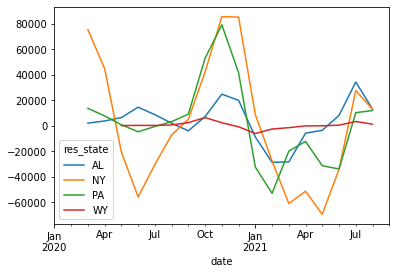

In [61]:
# plot all 7 day moving averages
covid_ts_state['ma3']\
    .unstack('res_state')\
    .plot()

## More functionality

There's much more functionality available within Pandas. For more on slicing, indexing, and datetime objects, read this article in the user guide:  

https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html  
https://pandas.pydata.org/pandas-docs/stable/user_guide/timedeltas.html
